# OBJECTIVE

The aim of this exercise is to engineer features from the results of the statistical tests (Spearman's correlation, Kruskal-Wallis and Mann-Whitney) to train the machine learning model to predict outcomes (Is_winner's 0 or 1) and combination of moves that leads to those outcomes.

In [9]:
# STEP 1 — Setup: imports and dataset loading
# This cell prepares all libraries and reads the cleaned dataset used by later steps.

# Import libraries and cleaned dataset for feature engineering
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

# Load the cleaned dataset using a robust path
candidate_paths = [
    Path('data file/Clean_Data/ludo_dataset_cleaned.csv'),
    Path('../data file/Clean_Data/ludo_dataset_cleaned.csv'),
    Path('data file/Raw_Data/ludo_dataset_cleaned.csv'),
    Path('../data file/Raw_Data/ludo_dataset_cleaned.csv'),
]

dataset_path = next((path for path in candidate_paths if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError('Could not find ludo_dataset_cleaned.csv in expected locations.')

# Read dataset into memory
df = pd.read_csv(dataset_path)
df.head(20)

,Game_ID,Turn,Player,Dice_Roll,Token_Moved,Position_Before,Position_After,Tokens_Home,Tokens_Active,Tokens_Finished,Captured_Opponent,Is_Winner
0,0,1,Red,6,1,0.0,1.0,3,1,0,0,0
1,0,2,Red,1,1,1.0,2.0,3,1,0,0,0
2,0,3,Green,6,3,0.0,1.0,3,1,0,0,0
3,0,4,Green,2,3,1.0,3.0,3,1,0,0,0
4,0,7,Red,6,1,2.0,8.0,3,1,0,0,0
5,0,8,Red,6,1,8.0,14.0,3,1,0,0,0
6,0,9,Red,5,1,14.0,19.0,3,1,0,0,0
7,0,10,Green,4,3,3.0,7.0,3,1,0,0,0
8,0,13,Red,1,1,19.0,20.0,3,1,0,0,0
9,0,14,Green,2,3,7.0,9.0,3,1,0,0,0


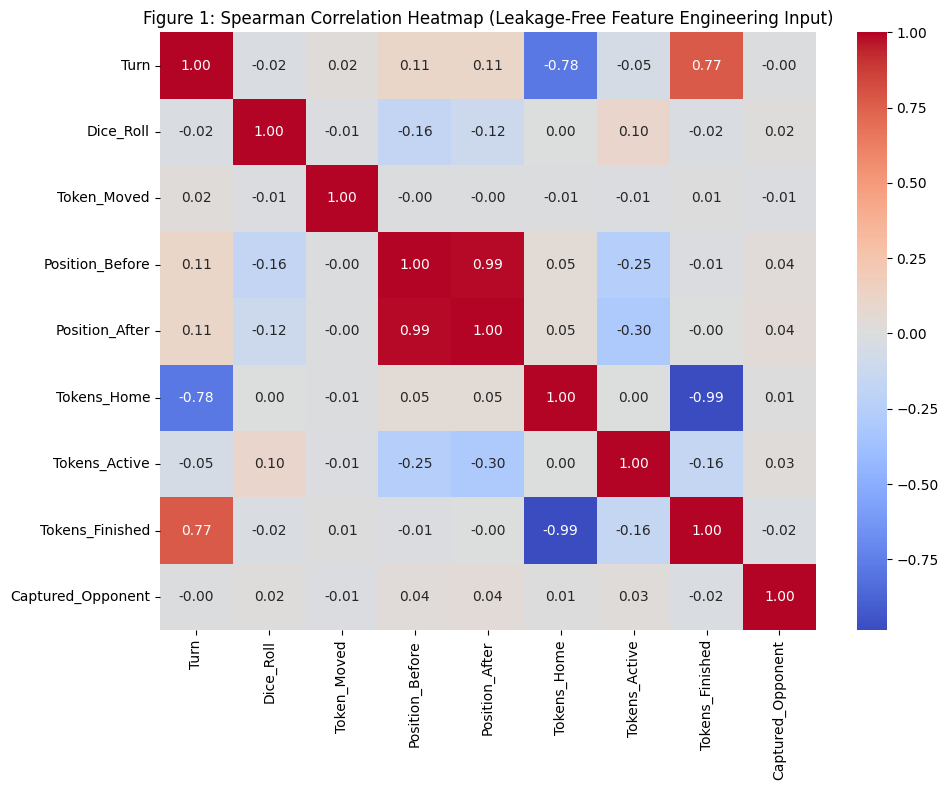

Imported Spearman correlation context from: Ludo_EDA.ipynb
Excluded columns from feature engineering: ['Is_Winner', 'Game_ID']


,feature_1,feature_2,spearman_rho,abs_rho,strength,direction
0,Position_Before,Position_After,0.987347,0.987347,Strong,Positive
1,Tokens_Home,Tokens_Finished,-0.985741,0.985741,Strong,Negative
2,Turn,Tokens_Home,-0.777921,0.777921,Strong,Negative
3,Turn,Tokens_Finished,0.774726,0.774726,Strong,Positive
4,Position_After,Tokens_Active,-0.298541,0.298541,Weak,Negative
5,Position_Before,Tokens_Active,-0.250533,0.250533,Weak,Negative
6,Dice_Roll,Position_Before,-0.164264,0.164264,Weak,Negative
7,Tokens_Active,Tokens_Finished,-0.161512,0.161512,Weak,Negative
8,Dice_Roll,Position_After,-0.115641,0.115641,Weak,Negative
9,Turn,Tokens_Active,-0.050348,0.050348,Weak,Negative


In [10]:
# STEP 2 — Correlation analysis input for feature engineering
# This cell builds a leakage-free Spearman correlation context and a filtered pair table.

# Spearman heatmap + categorized pairwise-correlation results
import json

# Optional validation: confirm Ludo_EDA contains the Spearman-correlation step
eda_notebook_candidates = [
    Path('jupyter_notebooks/Ludo_EDA.ipynb'),
    Path('Ludo_EDA.ipynb'),
    Path('../jupyter_notebooks/Ludo_EDA.ipynb'),
]
eda_notebook_path = next((p for p in eda_notebook_candidates if p.exists()), None)
if eda_notebook_path is None:
    raise FileNotFoundError('Could not find Ludo_EDA.ipynb in expected locations.')

with open(eda_notebook_path, 'r', encoding='utf-8') as f:
    eda_nb = json.load(f)

correlation_step_found = any(
    c.get('cell_type') == 'code' and
    "correlation_matrix = df_num.corr(method='spearman')" in ''.join(c.get('source', []))
    for c in eda_nb.get('cells', [])
)
if not correlation_step_found:
    raise ValueError('Spearman correlation step not found in Ludo_EDA.ipynb.')

# Compute Spearman correlation matrix without target and identifier columns to avoid leakage
excluded_for_engineering = ['Is_Winner', 'Game_ID']
df_num = df.select_dtypes(include=np.number).drop(columns=excluded_for_engineering, errors='ignore').copy()
correlation_matrix = df_num.corr(method='spearman')

# 1) Heatmap for quick relationship inspection
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Figure 1: Spearman Correlation Heatmap (Leakage-Free Feature Engineering Input)')
plt.tight_layout()
plt.show()

# 2) Categorized pairwise-correlation table
def classify_corr(rho):
    abs_rho = abs(rho)
    if abs_rho >= 0.7:
        strength = 'Strong'
    elif abs_rho >= 0.3:
        strength = 'Moderate'
    else:
        strength = 'Weak'

    direction = 'Positive' if rho > 0 else ('Negative' if rho < 0 else 'Neutral')
    return strength, direction

# Build pair list from upper triangle of correlation matrix
pairs = []
cols = correlation_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]
        rho = float(correlation_matrix.loc[f1, f2])
        strength, direction = classify_corr(rho)

        # Keep only requested categories (strong/moderate or any negative)
        keep = (strength in {'Strong', 'Moderate'}) or (direction == 'Negative')
        if keep:
            pairs.append({
                'feature_1': f1,
                'feature_2': f2,
                'spearman_rho': rho,
                'abs_rho': abs(rho),
                'strength': strength,
                'direction': direction,
            })

pairwise_correlation_results = (
    pd.DataFrame(pairs)
    .sort_values(['abs_rho', 'direction'], ascending=[False, True])
    .reset_index(drop=True)
)

print(f"Imported Spearman correlation context from: {eda_notebook_path}")
print(f"Excluded columns from feature engineering: {excluded_for_engineering}")
display(pairwise_correlation_results)

In [11]:
# STEP 3 — Feature engineering from correlation categories
# This cell creates engineered columns, applies uniform naming, and previews resulting features.

# Engineer features by correlation type, then drop source features used in engineering (except identifiers/target)
eps = 1e-6  # protects against division by zero
excluded_for_engineering = {'Is_Winner', 'Game_ID'}

# Rebuild pairwise table if it does not exist in memory
if 'pairwise_correlation_results' not in globals():
    pairs = []
    cols = correlation_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            f1, f2 = cols[i], cols[j]
            if f1 in excluded_for_engineering or f2 in excluded_for_engineering:
                continue
            rho = float(correlation_matrix.loc[f1, f2])
            abs_rho = abs(rho)
            if abs_rho >= 0.7:
                strength = 'Strong'
            elif abs_rho >= 0.3:
                strength = 'Moderate'
            else:
                strength = 'Weak'
            direction = 'Positive' if rho > 0 else ('Negative' if rho < 0 else 'Neutral')
            pairs.append({
                'feature_1': f1,
                'feature_2': f2,
                'spearman_rho': rho,
                'abs_rho': abs_rho,
                'strength': strength,
                'direction': direction,
            })
    pairwise_correlation_results = pd.DataFrame(pairs)

# Ensure no target/identifier-based pairs are used
pairwise_correlation_results = pairwise_correlation_results.loc[
    ~pairwise_correlation_results['feature_1'].isin(excluded_for_engineering)
    & ~pairwise_correlation_results['feature_2'].isin(excluded_for_engineering)
].reset_index(drop=True)

# --- Load Mann-Whitney U values from Ludo_EDA notebook (Step 6d) and convert to feature weights ---
import io
import json
from scipy.stats import mannwhitneyu

if 'eda_nb' not in globals():
    if 'eda_notebook_path' not in globals() or eda_notebook_path is None:
        eda_notebook_candidates = [
            Path('jupyter_notebooks/Ludo_EDA.ipynb'),
            Path('Ludo_EDA.ipynb'),
            Path('../jupyter_notebooks/Ludo_EDA.ipynb'),
        ]
        eda_notebook_path = next((p for p in eda_notebook_candidates if p.exists()), None)
        if eda_notebook_path is None:
            raise FileNotFoundError('Could not find Ludo_EDA.ipynb in expected locations.')

    with open(eda_notebook_path, 'r', encoding='utf-8') as f:
        eda_nb = json.load(f)

def _normalize_columns(df_in):
    out = df_in.copy()
    out.columns = [str(c).strip().lower().replace(' ', '_') for c in out.columns]
    rename_map = {
        'u_val': 'u_value',
        'u': 'u_value',
    }
    out = out.rename(columns=rename_map)
    return out

def _extract_mwu_from_eda_outputs(eda_notebook):
    marker = "mwu_df = pd.DataFrame(mwu_rows)"
    extracted = None

    for c in eda_notebook.get('cells', []):
        if c.get('cell_type') != 'code':
            continue
        src = ''.join(c.get('source', []))
        if marker not in src:
            continue

        for out in c.get('outputs', []):
            data = out.get('data', {}) if isinstance(out, dict) else {}
            html_payload = data.get('text/html')
            if html_payload:
                html_text = ''.join(html_payload) if isinstance(html_payload, list) else str(html_payload)
                try:
                    tables = pd.read_html(io.StringIO(html_text))
                except Exception:
                    tables = []
                for t in tables:
                    t = _normalize_columns(t)
                    required = {'numeric_variable', 'u_value', 'p_value', 'significant'}
                    if required.issubset(set(t.columns)):
                        extracted = t[list(required)].copy()
                        break
            if extracted is not None:
                break
        if extracted is not None:
            break

    return extracted

# 1) Preferred source: parse MWU results directly from Ludo_EDA notebook output table
mwu_df = _extract_mwu_from_eda_outputs(eda_nb)

# 2) Fallback source: last known MWU values from Ludo_EDA Step 6d result table
if mwu_df is None or mwu_df.empty:
    mwu_df = pd.DataFrame([
        {'numeric_variable': 'Turn', 'u_value': 11662408.5, 'p_value': 3.436587e-01, 'significant': False},
        {'numeric_variable': 'Dice_Roll', 'u_value': 11581509.0, 'p_value': 1.296232e-01, 'significant': False},
        {'numeric_variable': 'Token_Moved', 'u_value': 10872140.5, 'p_value': 1.309582e-10, 'significant': True},
        {'numeric_variable': 'Position_Before', 'u_value': 6805749.0, 'p_value': 2.839426e-07, 'significant': True},
        {'numeric_variable': 'Position_After', 'u_value': 6776655.0, 'p_value': 6.022537e-08, 'significant': True},
        {'numeric_variable': 'Tokens_Home', 'u_value': 15298936.0, 'p_value': 8.448305e-135, 'significant': True},
        {'numeric_variable': 'Tokens_Active', 'u_value': 11102690.5, 'p_value': 3.245883e-10, 'significant': True},
        {'numeric_variable': 'Tokens_Finished', 'u_value': 8518392.0, 'p_value': 1.033559e-120, 'significant': True},
        {'numeric_variable': 'Captured_Opponent', 'u_value': 11715264.5, 'p_value': 1.596819e-02, 'significant': True},
    ])

# 3) Final fallback: recompute MWU if table extraction/fallback is unavailable
if mwu_df is None or mwu_df.empty:
    alpha = 0.05
    mwu_rows = []
    numeric_features = [
        c for c in df.select_dtypes(include=np.number).columns
        if c not in excluded_for_engineering
    ]
    for col in numeric_features:
        x = df.loc[df['Is_Winner'] == 1, col].dropna()
        y = df.loc[df['Is_Winner'] == 0, col].dropna()

        if len(x) == 0 or len(y) == 0:
            mwu_rows.append({
                'numeric_variable': col,
                'u_value': np.nan,
                'p_value': np.nan,
                'significant': False,
            })
            continue

        u_stat, p_value = mannwhitneyu(x, y, alternative='two-sided')
        mwu_rows.append({
            'numeric_variable': col,
            'u_value': float(u_stat),
            'p_value': float(p_value),
            'significant': bool(p_value < alpha),
        })
    mwu_df = pd.DataFrame(mwu_rows)

# Standardize MWU table columns and dtypes
mwu_df = _normalize_columns(mwu_df)
required_cols = ['numeric_variable', 'u_value', 'p_value', 'significant']
for col in required_cols:
    if col not in mwu_df.columns:
        mwu_df[col] = np.nan
mwu_df = mwu_df[required_cols].copy()
mwu_df['numeric_variable'] = mwu_df['numeric_variable'].astype(str)
mwu_df['u_value'] = pd.to_numeric(mwu_df['u_value'], errors='coerce')
mwu_df['p_value'] = pd.to_numeric(mwu_df['p_value'], errors='coerce')
mwu_df['significant'] = mwu_df['significant'].astype(bool)

# Convert raw U values to a bounded separation weight
# We use distance from median(U) to approximate discriminatory separation across features.
u_valid = mwu_df['u_value'].dropna()
u_center = float(u_valid.median()) if not u_valid.empty else 0.0
u_scale = float((u_valid - u_center).abs().max()) if not u_valid.empty else 1.0
u_scale = u_scale if u_scale > 0 else 1.0

mwu_df['u_separation_weight'] = ((mwu_df['u_value'] - u_center).abs() / u_scale).clip(0.0, 1.0)
# De-emphasize non-significant variables but keep tiny contribution for stability
mwu_df['mwu_weight'] = np.where(mwu_df['significant'], mwu_df['u_separation_weight'], 0.15 * mwu_df['u_separation_weight'])

mwu_weight_lookup = mwu_df.set_index('numeric_variable')['mwu_weight'].to_dict()
significant_mwu_features = set(mwu_df.loc[mwu_df['significant'], 'numeric_variable'])

# Helper: normalize raw feature names for consistent engineered column naming
def normalize_feature_name(name):
    return ''.join(ch if ch.isalnum() else '_' for ch in str(name)).strip('_').lower()

# Helper: unified naming convention for engineered columns
def engineered_col_name(f1, f2, transform_tag):
    return f"eng_{transform_tag}__{normalize_feature_name(f1)}__{normalize_feature_name(f2)}"

# Start from clean copy of base data
df_fe = df.copy()

created_strong_pos = []
created_strong_neg = []
created_weak_neg = []

pending_columns = {}
source_features_used = set()

# Create engineered features by correlation category
# Combined weighting = Spearman rho scaled by MWU-derived pair weight from Ludo_EDA.
for _, row in pairwise_correlation_results.iterrows():
    f1 = row['feature_1']
    f2 = row['feature_2']
    strength = row['strength']
    direction = row['direction']
    rho = float(row['spearman_rho'])

    if rho == 0:
        continue

    # Fine-tune with Mann-Whitney evidence from Ludo_EDA Step 6d
    w1 = float(mwu_weight_lookup.get(f1, 0.0))
    w2 = float(mwu_weight_lookup.get(f2, 0.0))
    mwu_pair_weight = (w1 + w2) / 2.0

    # Require at least one source feature to be significant by MWU
    if (f1 not in significant_mwu_features) and (f2 not in significant_mwu_features):
        continue

    # Blend to keep a baseline Spearman signal while amplifying MWU-supported pairs
    combined_weight = rho * (0.25 + 0.75 * mwu_pair_weight)

    if strength == 'Strong' and direction == 'Positive':
        new_col = engineered_col_name(f1, f2, 'strong_pos_div_wrho_mwu')
        source_features_used.update([f1, f2])
        ratio = df_fe[f1] / (df_fe[f2] + eps)
        pending_columns[new_col] = ratio * combined_weight
        created_strong_pos.append(new_col)

    elif strength == 'Strong' and direction == 'Negative':
        new_col = engineered_col_name(f1, f2, 'strong_neg_mul_wrho_mwu')
        source_features_used.update([f1, f2])
        interaction = df_fe[f1] * df_fe[f2]
        pending_columns[new_col] = interaction * combined_weight
        created_strong_neg.append(new_col)

    elif strength == 'Weak' and direction == 'Negative':
        new_col = engineered_col_name(f1, f2, 'weak_neg_combo_wrho_mwu')
        source_features_used.update([f1, f2])
        ratio = df_fe[f1] / (df_fe[f2] + eps)
        safe_sqrt_term = np.sqrt(np.abs(ratio))
        combo = (df_fe[f1] * df_fe[f2]) - (safe_sqrt_term + ratio)
        pending_columns[new_col] = combo * combined_weight
        created_weak_neg.append(new_col)

# Append engineered features to dataframe
if pending_columns:
    df_fe = pd.concat([df_fe, pd.DataFrame(pending_columns, index=df_fe.index)], axis=1).copy()

# Drop source columns used to create engineered columns (except protected ones)
protected_columns = {'Game_ID', 'Is_Winner'}
drop_source_columns = sorted([
    col for col in source_features_used
    if col in df_fe.columns and col not in protected_columns
])
if drop_source_columns:
    df_fe = df_fe.drop(columns=drop_source_columns).copy()

# Progress summary
print(f"Strong positive features created: {len(created_strong_pos)}")
print(f"Strong negative features created: {len(created_strong_neg)}")
print(f"Weak negative features created: {len(created_weak_neg)}")
print(f"Original source features dropped (except Game_ID and Is_Winner): {len(drop_source_columns)}")
print(f"Excluded columns from feature engineering: {sorted(excluded_for_engineering)}")
print("Engineered feature naming format: eng_<transform>__<feature1>__<feature2>")
print("Combined weighting applied: engineered_feature = transform(feature_1, feature_2) * spearman_rho * (0.25 + 0.75 * mwu_pair_weight)")
print(f"MWU significant base features from Ludo_EDA: {len(significant_mwu_features)} / {mwu_df['numeric_variable'].nunique()}")

print('Top MWU-weighted base features (from Ludo_EDA Step 6d):')
display(mwu_df.sort_values(['significant', 'mwu_weight', 'p_value'], ascending=[False, False, True]).head(10))

# Preview engineered columns
preview_cols = [
    col for col in (created_strong_pos + created_strong_neg + created_weak_neg)
    if col in df_fe.columns
]
if preview_cols:
    display(df_fe[['Game_ID', 'Is_Winner'] + preview_cols].head())
else:
    print('No engineered columns available to preview.')

Strong positive features created: 2
Strong negative features created: 2
Weak negative features created: 17
Original source features dropped (except Game_ID and Is_Winner): 9
Excluded columns from feature engineering: ['Game_ID', 'Is_Winner']
Engineered feature naming format: eng_<transform>__<feature1>__<feature2>
Combined weighting applied: engineered_feature = transform(feature_1, feature_2) * spearman_rho * (0.25 + 0.75 * mwu_pair_weight)
MWU significant base features from Ludo_EDA: 7 / 9
Top MWU-weighted base features (from Ludo_EDA Step 6d):


,numeric_variable,u_value,p_value,significant,u_separation_weight,mwu_weight
4,Position_After,6776655.0,6.022537e-08,True,1.000000,1.000000
3,Position_Before,6805749.0,2.839426e-07,True,0.993275,0.993275
5,Tokens_Home,15298936.0,8.448305e-135,True,0.969998,0.969998
7,Tokens_Finished,8518392.0,1.033559e-120,True,0.597383,0.597383
8,Captured_Opponent,11715264.5,1.596819e-02,True,0.141602,0.141602
2,Token_Moved,10872140.5,1.309582e-10,True,0.053294,0.053294
6,Tokens_Active,11102690.5,3.245883e-10,True,0.000000,0.000000
0,Turn,11662408.5,3.436587e-01,False,0.129384,0.019408
1,Dice_Roll,11581509.0,1.296232e-01,False,0.110683,0.016602


,Game_ID,Is_Winner,eng_strong_pos_div_wrho_mwu__position_before__position_after,eng_strong_pos_div_wrho_mwu__turn__tokens_finished,eng_strong_neg_mul_wrho_mwu__tokens_home__tokens_finished,eng_strong_neg_mul_wrho_mwu__turn__tokens_home,eng_weak_neg_combo_wrho_mwu__position_after__tokens_active,eng_weak_neg_combo_wrho_mwu__position_before__tokens_active,eng_weak_neg_combo_wrho_mwu__dice_roll__position_before,eng_weak_neg_combo_wrho_mwu__tokens_active__tokens_finished,...,eng_weak_neg_combo_wrho_mwu__dice_roll__tokens_finished,eng_weak_neg_combo_wrho_mwu__token_moved__captured_opponent,eng_weak_neg_combo_wrho_mwu__dice_roll__token_moved,eng_weak_neg_combo_wrho_mwu__token_moved__tokens_active,eng_weak_neg_combo_wrho_mwu__position_before__tokens_finished,eng_weak_neg_combo_wrho_mwu__token_moved__tokens_home,eng_weak_neg_combo_wrho_mwu__token_moved__position_before,eng_weak_neg_combo_wrho_mwu__token_moved__position_after,eng_weak_neg_combo_wrho_mwu__turn__captured_opponent,eng_weak_neg_combo_wrho_mwu__position_after__tokens_finished
0,0,0,0.000000,3.728725e+05,-0.0,-1.449331,0.186588,-0.000000,619892.194320,76636.437524,...,52512.874812,4354.077510,0.008240,0.002352,-0.000000,-0.008086,3073.569008,0.002465,1115.641758,108.785258
1,0,0,0.492428,7.457451e+05,-0.0,-2.898662,0.263875,0.155951,0.103273,76636.437524,...,8757.322786,4354.077510,0.003364,0.002352,7105.011183,-0.008086,0.003070,-0.001954,2230.630642,217.506855
2,0,0,0.000000,1.118618e+06,-0.0,-4.347992,0.186588,-0.000000,619892.194320,76636.437524,...,52512.874812,13056.717295,-0.049064,0.004073,-0.000000,-0.027091,9216.813789,0.004269,3345.512111,108.785258
3,0,0,0.328285,1.491490e+06,-0.0,-5.797323,0.323179,0.155951,0.146050,76636.437524,...,17509.520775,13056.717295,-0.015194,0.004073,7105.011183,-0.027091,0.005318,-0.017252,4460.337979,326.217977
4,0,0,0.246214,2.610108e+06,-0.0,-10.145315,0.527749,0.220548,-0.750585,76636.437524,...,52512.874812,4354.077510,0.008240,0.002352,14205.864505,-0.008086,-0.002435,-0.018538,7804.639380,869.720035


In [12]:

# STEP 3b — MWU post-weighting of correlation-engineered features
# Each engineered column was created with a blended Spearman-rho * MWU weight.
# This cell applies a *second*, additive MWU pass using the per-feature separation
# weights from Ludo_EDA (mwu_weight_lookup), reinforcing discrimination between
# winners and non-winners independently of the original Spearman scaling.

# Build a normalized lookup so column-embedded names (e.g. 'tokens_home') resolve
# to the same MWU weight as the original feature name (e.g. 'Tokens_Home').
norm_mwu_lookup = {
    normalize_feature_name(k): v
    for k, v in mwu_weight_lookup.items()
}

eng_cols_all = [col for col in df_fe.columns if col.startswith('eng_')]
mwu_reweight_rows = []

for col in eng_cols_all:
    # Naming format: eng_<transform>__<f1_norm>__<f2_norm>
    parts = col.split('__')
    if len(parts) < 3:
        continue

    f1_norm = parts[1]
    f2_norm = parts[2]

    w1 = norm_mwu_lookup.get(f1_norm, 0.0)
    w2 = norm_mwu_lookup.get(f2_norm, 0.0)

    # Pair-level extra weight: average of the two source-feature MWU weights.
    # Guarded with a floor of 0.1 so no engineered column is fully zeroed out.
    mwu_extra = max((w1 + w2) / 2.0, 0.1)

    df_fe[col] = df_fe[col] * mwu_extra

    mwu_reweight_rows.append({
        'engineered_feature': col,
        'f1_norm': f1_norm,
        'f2_norm': f2_norm,
        'mwu_w1': round(w1, 5),
        'mwu_w2': round(w2, 5),
        'extra_weight_applied': round(mwu_extra, 5),
    })

mwu_reweight_summary = (
    pd.DataFrame(mwu_reweight_rows)
    .sort_values('extra_weight_applied', ascending=False)
    .reset_index(drop=True)
)

print(f"MWU post-weighting applied to {len(eng_cols_all)} engineered feature(s).")
print("Formula: eng_col  ←  eng_col  ×  max(mean(mwu_w(f1), mwu_w(f2)), 0.10)")
print("(Weight floor of 0.10 prevents zeroing out low-U features completely.)")
display(mwu_reweight_summary)

# Preview top-weighted engineered columns after scaling
top_preview = mwu_reweight_summary['engineered_feature'].head(5).tolist()
if top_preview:
    display(df_fe[['Game_ID', 'Is_Winner'] + top_preview].head())


MWU post-weighting applied to 21 engineered feature(s).
Formula: eng_col  ←  eng_col  ×  max(mean(mwu_w(f1), mwu_w(f2)), 0.10)
(Weight floor of 0.10 prevents zeroing out low-U features completely.)


,engineered_feature,f1_norm,f2_norm,mwu_w1,mwu_w2,extra_weight_applied
0,eng_strong_pos_div_wrho_mwu__position_before__...,position_before,position_after,0.99327,1.00000,0.99664
1,eng_weak_neg_combo_wrho_mwu__position_after__t...,position_after,tokens_finished,1.00000,0.59738,0.79869
2,eng_weak_neg_combo_wrho_mwu__position_before__...,position_before,tokens_finished,0.99327,0.59738,0.79533
3,eng_strong_neg_mul_wrho_mwu__tokens_home__toke...,tokens_home,tokens_finished,0.97000,0.59738,0.78369
4,eng_weak_neg_combo_wrho_mwu__token_moved__posi...,token_moved,position_after,0.05329,1.00000,0.52665
5,eng_weak_neg_combo_wrho_mwu__token_moved__posi...,token_moved,position_before,0.05329,0.99327,0.52328
6,eng_weak_neg_combo_wrho_mwu__token_moved__toke...,token_moved,tokens_home,0.05329,0.97000,0.51165
7,eng_weak_neg_combo_wrho_mwu__dice_roll__positi...,dice_roll,position_after,0.01660,1.00000,0.50830
8,eng_weak_neg_combo_wrho_mwu__dice_roll__positi...,dice_roll,position_before,0.01660,0.99327,0.50494
9,eng_weak_neg_combo_wrho_mwu__position_after__t...,position_after,tokens_active,1.00000,0.00000,0.50000


,Game_ID,Is_Winner,eng_strong_pos_div_wrho_mwu__position_before__position_after,eng_weak_neg_combo_wrho_mwu__position_after__tokens_finished,eng_weak_neg_combo_wrho_mwu__position_before__tokens_finished,eng_strong_neg_mul_wrho_mwu__tokens_home__tokens_finished,eng_weak_neg_combo_wrho_mwu__token_moved__position_after
0,0,0,0.000000,86.885841,-0.000000,-0.0,0.001298
1,0,0,0.490772,173.720837,5650.818995,-0.0,-0.001029
2,0,0,0.000000,86.885841,-0.000000,-0.0,0.002248
3,0,0,0.327182,260.547467,5650.818995,-0.0,-0.009086
4,0,0,0.245386,694.637842,11298.331124,-0.0,-0.009763


Training set shape: (6844, 25), Test set shape: (1712, 25)
Model trained
Classification report


,precision,recall,f1-score,support
0,0.813,0.948,0.876,1254.000
1,0.740,0.404,0.523,458.000
accuracy,0.803,0.803,0.803,0.803
macro avg,0.777,0.676,0.699,1712.000
weighted avg,0.794,0.803,0.781,1712.000


Confusion matrix


,Predicted 0,Predicted 1
Actual 0,1189,65
Actual 1,273,185


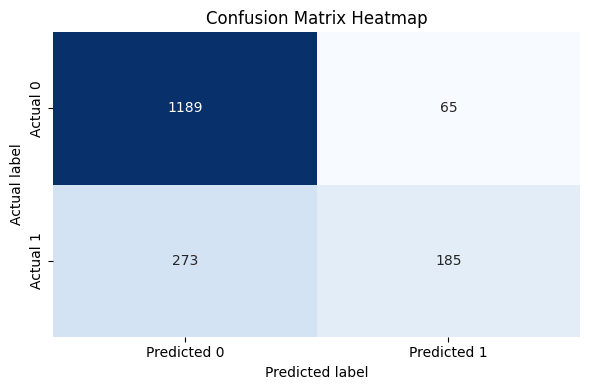

In [13]:
# STEP 4 — Baseline model training and evaluation
# This cell trains a baseline pipeline on engineered features and reports classification results.

# Training the model on correlation engineered features and comparing performance to a baseline model trained on original features (except those dropped due to engineering).
X = pd.get_dummies(df_fe.drop(columns=['Game_ID', 'Is_Winner']), drop_first=False)
y = df_fe['Is_Winner']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

# Build baseline pipeline
P = Pipeline([
    ('scaler', StandardScaler()),
    ('feat_selection', SelectFromModel(GradientBoostingClassifier(random_state=101))),
    ('model', GradientBoostingClassifier(random_state=101))
])

# Fit baseline model and make predictions
P.fit(X_train, y_train)
print("Model trained")
y_preds = P.predict(X_test)

# Reusable evaluation helper (table + confusion matrix + heatmap)
def model_evaluation(y_test, y_preds):
    report_df = pd.DataFrame(
        classification_report(y_test, y_preds, output_dict=True)
    ).transpose().round(3)
    confusion_df = pd.DataFrame(
        confusion_matrix(y_test, y_preds),
        index=['Actual 0', 'Actual 1'],
        columns=['Predicted 0', 'Predicted 1']
    )

    print("Classification report")
    display(report_df)
    print("Confusion matrix")
    display(confusion_df)

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_df, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Confusion Matrix Heatmap')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

    return report_df, confusion_df

# Evaluate baseline model
model_report, model_confusion = model_evaluation(y_test, y_preds)

Constraint floors used in tuning
Minimum validation accuracy: 0.783
Minimum validation precision (class 1): 0.640
Best tuning configuration (balanced constraints)


,feasible,positive_class_weight,threshold,validation_accuracy,validation_precision_class_1,validation_recall_class_1,validation_f1_class_1,tuning_score,feat_selection__threshold,model__learning_rate,model__max_depth,model__n_estimators
0,True,2.5,0.55,0.806,0.644,0.681,0.662,1000.689,median,0.1,3,200


Top tuning results


,feasible,positive_class_weight,threshold,validation_accuracy,validation_precision_class_1,validation_recall_class_1,validation_f1_class_1,tuning_score,feat_selection__threshold,model__learning_rate,model__max_depth,model__n_estimators
0,True,2.5,0.55,0.806,0.644,0.681,0.662,1000.689,median,0.10,3,200
1,True,3.0,0.60,0.804,0.642,0.673,0.657,1000.683,median,0.10,3,200
2,True,1.5,0.45,0.812,0.661,0.670,0.666,1000.683,median,0.10,3,200
3,True,2.0,0.50,0.806,0.646,0.670,0.658,1000.681,median,0.10,3,200
4,True,2.0,0.50,0.801,0.640,0.657,0.649,1000.670,median,0.05,3,200
5,True,2.0,0.50,0.805,0.649,0.654,0.652,1000.669,median,0.10,3,100
6,True,1.5,0.45,0.810,0.664,0.647,0.655,1000.665,median,0.10,3,100
7,True,1.5,0.45,0.801,0.642,0.649,0.646,1000.664,median,0.05,3,100
8,True,1.5,0.45,0.806,0.654,0.644,0.649,1000.661,median,0.05,3,200
9,True,2.5,0.60,0.814,0.679,0.631,0.654,1000.654,median,0.10,3,100


Tuned model evaluation on the test set
Classification report


,precision,recall,f1-score,support
0,0.868,0.841,0.854,1254.00
1,0.598,0.651,0.623,458.00
accuracy,0.790,0.790,0.790,0.79
macro avg,0.733,0.746,0.739,1712.00
weighted avg,0.796,0.790,0.792,1712.00


Confusion matrix


,Predicted 0,Predicted 1
Actual 0,1054,200
Actual 1,160,298


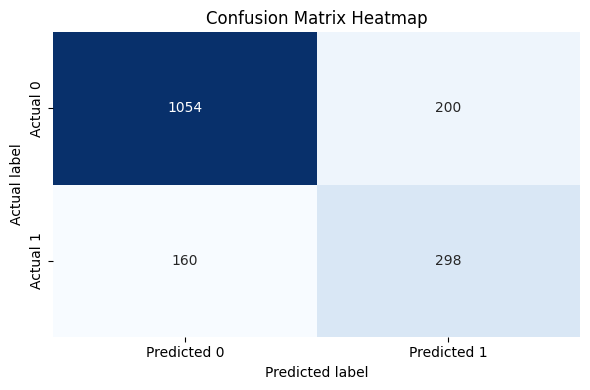

Baseline vs tuned summary


,baseline_accuracy,baseline_recall_class_1,baseline_f1_class_1,baseline_precision_class_1,tuned_accuracy,tuned_recall_class_1,tuned_f1_class_1,tuned_precision_class_1
0,0.803,0.404,0.523,0.74,0.79,0.651,0.623,0.598


In [14]:
# STEP 5 — Hyperparameter tuning with class-weight and threshold search (balanced constraints)
# This cell improves winner recall while protecting overall accuracy and winner precision.

from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import ParameterGrid

# Create a validation split from the training data for tuning.
X_tune_train, X_val, y_tune_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=101,
    stratify=y_train
)

# Baseline-derived safety floors (to avoid collapsing accuracy/precision)
baseline_acc = float(model_report.loc['accuracy', 'precision']) if 'model_report' in globals() else 0.80
baseline_precision_1 = float(model_report.loc['1', 'precision']) if 'model_report' in globals() else 0.70

min_accuracy = max(0.0, baseline_acc - 0.02)          # allow at most ~2 points drop
min_precision_class_1 = max(0.0, baseline_precision_1 - 0.10)  # allow some precision trade-off

# Candidate search space
param_grid = {
    'feat_selection__threshold': ['median', 'mean'],
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3],
}
positive_class_weights = [1.0, 1.5, 2.0, 2.5, 3.0]

# Include both moderate and conservative thresholds to recover precision/accuracy
threshold_candidates = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75]

best_result = None
best_score = -np.inf
tuning_rows = []

# Grid search over params + class weights + thresholds
for params in ParameterGrid(param_grid):
    for positive_weight in positive_class_weights:
        candidate_model = clone(P)
        candidate_model.set_params(**params)

        tune_sample_weight = np.where(y_tune_train == 1, positive_weight, 1.0)
        candidate_model.fit(
            X_tune_train,
            y_tune_train,
            feat_selection__sample_weight=tune_sample_weight,
            model__sample_weight=tune_sample_weight
        )

        val_probs = candidate_model.predict_proba(X_val)[:, 1]

        for threshold in threshold_candidates:
            val_preds = (val_probs >= threshold).astype(int)
            precision_1 = precision_score(y_val, val_preds, pos_label=1, zero_division=0)
            recall_1 = recall_score(y_val, val_preds, pos_label=1, zero_division=0)
            f1_1 = f1_score(y_val, val_preds, pos_label=1, zero_division=0)
            accuracy = accuracy_score(y_val, val_preds)

            # Constrained ranking:
            # 1) Prefer configs that keep accuracy/precision near baseline.
            # 2) Among feasible configs, maximize winner recall.
            feasible = (accuracy >= min_accuracy) and (precision_1 >= min_precision_class_1)
            acc_gap = max(0.0, min_accuracy - accuracy)
            prec_gap = max(0.0, min_precision_class_1 - precision_1)

            if feasible:
                tuning_score = 1000.0 + (0.70 * recall_1) + (0.20 * f1_1) + (0.10 * accuracy)
            else:
                # Fallback score with strong penalties for violating floors
                penalty = (2.0 * acc_gap) + (2.0 * prec_gap)
                tuning_score = (0.40 * recall_1) + (0.25 * f1_1) + (0.20 * precision_1) + (0.15 * accuracy) - penalty

            row = {
                'feasible': feasible,
                'positive_class_weight': positive_weight,
                'threshold': threshold,
                'validation_accuracy': round(accuracy, 3),
                'validation_precision_class_1': round(precision_1, 3),
                'validation_recall_class_1': round(recall_1, 3),
                'validation_f1_class_1': round(f1_1, 3),
                'tuning_score': round(tuning_score, 3),
                **params,
            }
            tuning_rows.append(row)

            if tuning_score > best_score:
                best_score = tuning_score
                best_result = row.copy()
                best_params = params.copy()
                best_threshold = threshold
                best_positive_weight = positive_weight

# Retrain the tuned model on the full training split.
tuned_model = clone(P)
tuned_model.set_params(**best_params)
full_sample_weight = np.where(y_train == 1, best_positive_weight, 1.0)
tuned_model.fit(
    X_train,
    y_train,
    feat_selection__sample_weight=full_sample_weight,
    model__sample_weight=full_sample_weight
)

# Predict probabilities and apply best threshold
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]
tuned_y_preds = (tuned_probs >= best_threshold).astype(int)

# Rank and show top tuning runs
tuning_results = pd.DataFrame(tuning_rows).sort_values(
    by=['feasible', 'tuning_score', 'validation_recall_class_1', 'validation_f1_class_1'],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print('Constraint floors used in tuning')
print(f"Minimum validation accuracy: {min_accuracy:.3f}")
print(f"Minimum validation precision (class 1): {min_precision_class_1:.3f}")
print('Best tuning configuration (balanced constraints)')
display(pd.DataFrame([best_result]))
print('Top tuning results')
display(tuning_results.head(10))
print('Tuned model evaluation on the test set')
tuned_report, tuned_confusion = model_evaluation(y_test, tuned_y_preds)

# Baseline vs tuned summary table
if 'model_report' in globals():
    baseline_summary = {
        'baseline_accuracy': round(float(model_report.loc['accuracy', 'precision']), 3),
        'baseline_recall_class_1': round(float(model_report.loc['1', 'recall']), 3),
        'baseline_f1_class_1': round(float(model_report.loc['1', 'f1-score']), 3),
        'baseline_precision_class_1': round(float(model_report.loc['1', 'precision']), 3),
    }
    tuned_summary = {
        'tuned_accuracy': round(float(tuned_report.loc['accuracy', 'precision']), 3),
        'tuned_recall_class_1': round(float(tuned_report.loc['1', 'recall']), 3),
        'tuned_f1_class_1': round(float(tuned_report.loc['1', 'f1-score']), 3),
        'tuned_precision_class_1': round(float(tuned_report.loc['1', 'precision']), 3),
    }
    print('Baseline vs tuned summary')
    display(pd.DataFrame([baseline_summary | tuned_summary]))

In [ ]:
# STEP 5b — Cross-validated robustness check for tuned model
# This cell verifies whether the tuned configuration is stable across folds.

from sklearn.model_selection import StratifiedKFold

# Rebuild full feature matrix from engineered dataset
X_full = pd.get_dummies(df_fe.drop(columns=['Game_ID', 'Is_Winner']), drop_first=False)
y_full = df_fe['Is_Winner'].astype(int)

# Ensure tuned settings exist (fallbacks keep this cell runnable)
cv_best_params = best_params if 'best_params' in globals() else {
    'feat_selection__threshold': 'median',
    'model__n_estimators': 200,
    'model__learning_rate': 0.1,
    'model__max_depth': 3,
}
cv_best_weight = float(best_positive_weight) if 'best_positive_weight' in globals() else 2.5
cv_best_threshold = float(best_threshold) if 'best_threshold' in globals() else 0.55

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=101)
cv_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X_full, y_full), start=1):
    X_tr, X_te = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_tr, y_te = y_full.iloc[train_idx], y_full.iloc[test_idx]

    fold_model = clone(P)
    fold_model.set_params(**cv_best_params)

    fold_sw = np.where(y_tr == 1, cv_best_weight, 1.0)
    fold_model.fit(
        X_tr,
        y_tr,
        feat_selection__sample_weight=fold_sw,
        model__sample_weight=fold_sw
    )

    fold_probs = fold_model.predict_proba(X_te)[:, 1]
    fold_preds = (fold_probs >= cv_best_threshold).astype(int)

    fold_acc = accuracy_score(y_te, fold_preds)
    fold_prec_1 = precision_score(y_te, fold_preds, pos_label=1, zero_division=0)
    fold_rec_1 = recall_score(y_te, fold_preds, pos_label=1, zero_division=0)
    fold_f1_1 = f1_score(y_te, fold_preds, pos_label=1, zero_division=0)

    cv_rows.append({
        'fold': fold_idx,
        'accuracy': fold_acc,
        'precision_class_1': fold_prec_1,
        'recall_class_1': fold_rec_1,
        'f1_class_1': fold_f1_1,
    })

cv_results = pd.DataFrame(cv_rows)
cv_summary = pd.DataFrame([{
    'mean_accuracy': cv_results['accuracy'].mean(),
    'std_accuracy': cv_results['accuracy'].std(ddof=1),
    'mean_precision_class_1': cv_results['precision_class_1'].mean(),
    'std_precision_class_1': cv_results['precision_class_1'].std(ddof=1),
    'mean_recall_class_1': cv_results['recall_class_1'].mean(),
    'std_recall_class_1': cv_results['recall_class_1'].std(ddof=1),
    'mean_f1_class_1': cv_results['f1_class_1'].mean(),
    'std_f1_class_1': cv_results['f1_class_1'].std(ddof=1),
}]).round(3)

print('Cross-validation setup')
print(f'Params: {cv_best_params}')
print(f'Positive class weight: {cv_best_weight}')
print(f'Threshold: {cv_best_threshold}')
print('Per-fold results')
display(cv_results.round(3))
print('Cross-validated summary (mean ± std)')
display(cv_summary)

# Deployment-oriented quick check
acc_ok = cv_summary.loc[0, 'std_accuracy'] <= 0.015
recall_ok = cv_summary.loc[0, 'mean_recall_class_1'] >= 0.60
f1_ok = cv_summary.loc[0, 'mean_f1_class_1'] >= 0.60

cv_deploy_readiness = pd.DataFrame([{
    'accuracy_stability_ok(std<=0.015)': bool(acc_ok),
    'winner_recall_ok(mean>=0.60)': bool(recall_ok),
    'winner_f1_ok(mean>=0.60)': bool(f1_ok),
    'overall_cv_gate_pass': bool(acc_ok and recall_ok and f1_ok),
}])

print('Model-only CV readiness gate')
display(cv_deploy_readiness)


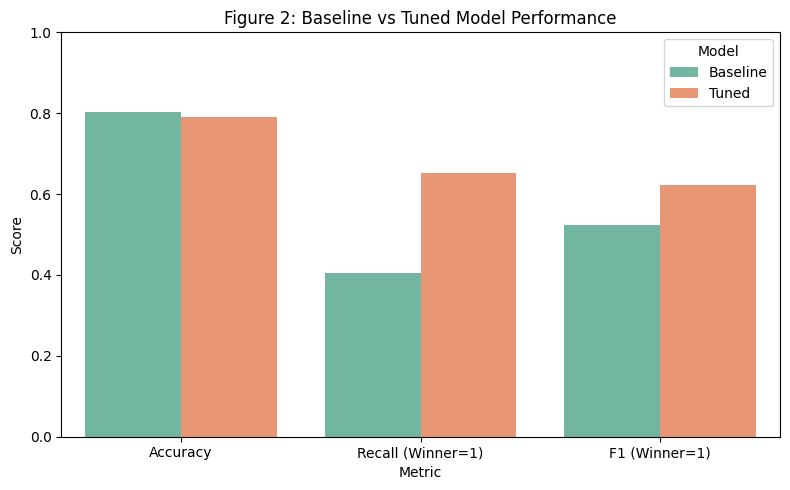

Saved tuned pipeline artifact to: /home/chizoalban2003/ludomaniac/jupyter_notebooks/artifacts/tuned_ludo_pipeline.pkl


In [15]:
# STEP 6 — Compare baseline vs tuned model and save tuned artifact
# This cell plots key metrics and persists the tuned pipeline for later inference.

# Plot baseline vs tuned metrics, then save the tuned pipeline for future use.
import joblib

# Build comparison table (recompute if summaries are not in memory)
if 'baseline_summary' not in globals() and 'model_report' in globals():
    baseline_summary = {
        'baseline_accuracy': round(float(model_report.loc['accuracy', 'precision']), 3),
        'baseline_recall_class_1': round(float(model_report.loc['1', 'recall']), 3),
        'baseline_f1_class_1': round(float(model_report.loc['1', 'f1-score']), 3),
    }

if 'tuned_summary' not in globals() and 'tuned_report' in globals():
    tuned_summary = {
        'tuned_accuracy': round(float(tuned_report.loc['accuracy', 'precision']), 3),
        'tuned_recall_class_1': round(float(tuned_report.loc['1', 'recall']), 3),
        'tuned_f1_class_1': round(float(tuned_report.loc['1', 'f1-score']), 3),
    }

# Create side-by-side comparison dataframe
comparison_df = pd.DataFrame([
    {
        'metric': 'Accuracy',
        'Baseline': baseline_summary['baseline_accuracy'],
        'Tuned': tuned_summary['tuned_accuracy'],
    },
    {
        'metric': 'Recall (Winner=1)',
        'Baseline': baseline_summary['baseline_recall_class_1'],
        'Tuned': tuned_summary['tuned_recall_class_1'],
    },
    {
        'metric': 'F1 (Winner=1)',
        'Baseline': baseline_summary['baseline_f1_class_1'],
        'Tuned': tuned_summary['tuned_f1_class_1'],
    },
])

comparison_long = comparison_df.melt(id_vars='metric', var_name='Model', value_name='Score')

# Plot baseline vs tuned scores
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_long, x='metric', y='Score', hue='Model', palette='Set2')
plt.ylim(0, 1)
plt.title('Figure 2: Baseline vs Tuned Model Performance')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.tight_layout()
plt.show()

# Save tuned pipeline + threshold metadata
artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

tuned_artifact = {
    'pipeline': tuned_model,
    'decision_threshold': best_threshold,
    'positive_class_weight': best_positive_weight,
    'best_params': best_params,
    'feature_columns': X_train.columns.tolist(),
}

model_path = artifacts_dir / 'tuned_ludo_pipeline.pkl'
joblib.dump(tuned_artifact, model_path)
print(f"Saved tuned pipeline artifact to: {model_path.resolve()}")

Top 10 feature importances from the tuned model


,feature,importance
0,eng_strong_neg_mul_wrho_mwu__turn__tokens_home,0.378080
1,eng_weak_neg_combo_wrho_mwu__token_moved__toke...,0.182829
2,Player_Red,0.125393
3,eng_weak_neg_combo_wrho_mwu__turn__captured_op...,0.085814
4,Player_Blue,0.038762
5,eng_weak_neg_combo_wrho_mwu__token_moved__posi...,0.034642
6,eng_strong_pos_div_wrho_mwu__turn__tokens_fini...,0.032728
7,eng_weak_neg_combo_wrho_mwu__dice_roll__tokens...,0.028069
8,eng_weak_neg_combo_wrho_mwu__dice_roll__positi...,0.026413
9,eng_weak_neg_combo_wrho_mwu__position_after__t...,0.025391


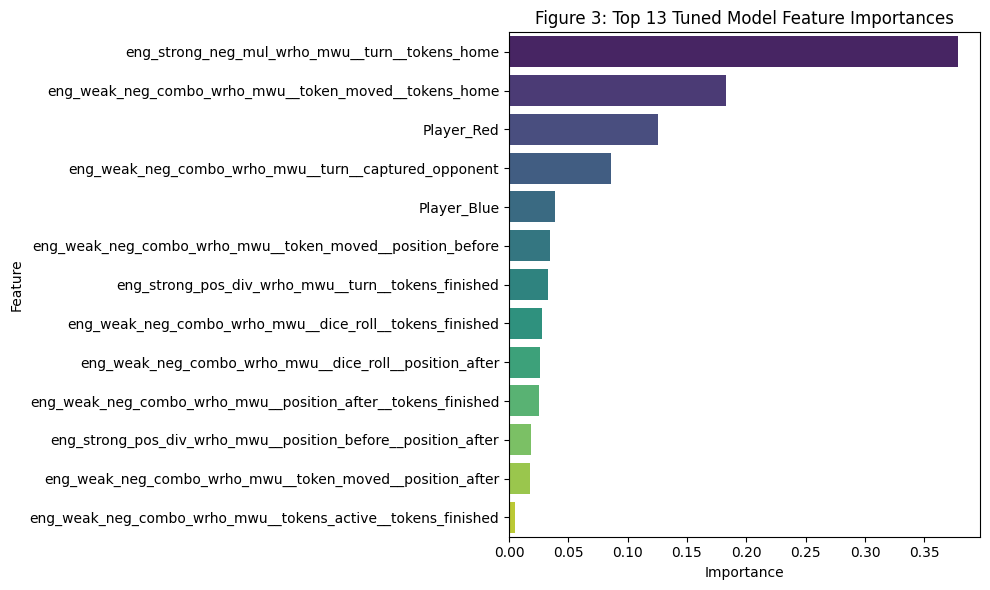

In [16]:
# STEP 7 — Feature importance view from the tuned pipeline
# This cell aligns model importances with selected features and plots the top contributors.

# Feature importance from the tuned model
if hasattr(tuned_model.named_steps['model'], 'feature_importances_'):
    importances = tuned_model.named_steps['model'].feature_importances_

    # Map importances to the feature subset kept by SelectFromModel
    support_mask = tuned_model.named_steps['feat_selection'].get_support()
    selected_feature_names = X_train.columns[support_mask]

    importance_df = pd.DataFrame({
        'feature': selected_feature_names,
        'importance': importances
    }).sort_values(by='importance', ascending=False).reset_index(drop=True)

    print("Top 10 feature importances from the tuned model")
    display(importance_df.head(10))

    # Plot top features for easier interpretation
    top_n = min(15, len(importance_df))
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=importance_df.head(top_n),
        x='importance',
        y='feature',
        hue='feature',
        palette='viridis',
        legend=False
    )
    plt.title(f'Figure 3: Top {top_n} Tuned Model Feature Importances')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("The tuned model does not expose feature importances.")